# Predictive Analytics for Brasileirão: A Data Driven Business Strategy for Sports Intelligence

**Final Data Science Assignment**

This notebook turns historical Brasileirão data into a compact sports intelligence prototype. The goal is not only to train a classifier, but to show how football clubs, sports media platforms, and fantasy sports products can use match prediction signals to support planning, content, and user engagement.


## 1. Introduction

Football organizations make repeated decisions under uncertainty: which matches deserve deeper tactical attention, which teams are gaining momentum, and how to present upcoming fixtures to fans. Predictive analytics can help convert historical match data into clear probability signals.

This project uses Brasileirão historical data to estimate match outcomes: home win, away win, or draw.


## 2. Business Problem

Sports organizations need fast, explainable signals about likely match outcomes. A prediction model can support three practical audiences:

- **Football clubs:** opponent analysis and match preparation.
- **Sports media platforms:** richer previews and data-driven match storytelling.
- **Fantasy sports products:** engagement features based on team strength and fixture difficulty.

The business question is: **Can historical standings and match results provide useful prediction signals for upcoming Brasileirão fixtures?**


## 3. Market Context

Sports intelligence products are valuable because they transform raw competition data into decisions and content. For this project, the product vision is a lightweight analytics layer that can be embedded into dashboards, editorial tools, or fantasy sports experiences.

The model should be treated as a decision-support signal, not as an automatic decision maker.


## 4. Dataset Description

The project uses the local file `IA_FUTEBOL_DADOS.zip`, which contains:

- `dataset-2003-2022.csv`: season standings and team performance by year.
- `campeonato-brasileiro-full.csv`: match-level records.
- `campeonato-brasileiro-gols.csv`: goal-level records.

The analysis focuses on the period from 2003 to 2022 so the standings and match datasets stay aligned.


In [ ]:
## install dependencies
!pip install -r requirements.txt

In [15]:
import warnings
from pathlib import Path
from zipfile import ZipFile

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

from sklearn.exceptions import UndefinedMetricWarning
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import shuffle

sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

DATA_ZIP = Path("IA_FUTEBOL_DADOS.zip")
if not DATA_ZIP.exists():
    raise FileNotFoundError("IA_FUTEBOL_DADOS.zip must be in the project root.")

with ZipFile(DATA_ZIP) as archive:
    ranking = pd.read_csv(archive.open("IA_FUTEBOL_DADOS/dataset-2003-2022.csv"))
    matches = pd.read_csv(archive.open("IA_FUTEBOL_DADOS/campeonato-brasileiro-full.csv"))
    goals = pd.read_csv(archive.open("IA_FUTEBOL_DADOS/campeonato-brasileiro-gols.csv"))

print("Ranking dataset:", ranking.shape)
print("Matches dataset:", matches.shape)
print("Goals dataset:", goals.shape)


Ranking dataset: (410, 12)
Matches dataset: (8025, 16)
Goals dataset: (7986, 6)


## 5. Data Cleaning and Preparation

The original datasets use slightly different spellings for some clubs. The next step standardizes team names so standings and match records can be joined conceptually and compared consistently.


In [16]:
# Standardize team names across datasets.
team_name_replacements = {
    "América Mineiro": "America-MG",
    "América-MG": "America-MG",
    "Athletico Paranaense": "Athletico-PR",
    "Athlético Paranaense": "Athletico-PR",
    "Atlético Paranaense": "Athletico-PR",
    "Atlético Mineiro": "Atletico-MG",
    "Atlético Goianiense": "Atletico-GO",
    "Avaí": "Avai",
    "Ceará": "Ceara",
    "Criciúma": "Criciuma",
    "Cuiabá": "Cuiaba",
    "Goiás": "Goias",
    "Grêmio": "Gremio",
    "Paraná": "Parana",
    "São Paulo": "Sao Paulo",
    "Vasco da Gama": "Vasco",
    "Vitória": "Vitoria",
}

ranking["team"] = ranking["team"].str.strip().replace(team_name_replacements)
ranking.head()


,year,position,team,points,games,victories,draws,losses,goals_scored,goals_against,goals_difference,perc_points_won
0,2003,1,Cruzeiro,100,46,31,7,8,102,47,55,72
1,2003,2,Santos,87,46,25,12,9,93,60,33,63
2,2003,3,Sao Paulo,78,46,22,12,12,81,67,14,56
3,2003,4,São Caetano,74,46,19,14,13,53,37,16,53
4,2003,5,Coritiba,73,46,21,10,15,67,58,9,52


The cleaned standings table provides long-term context: points, victories, draws, losses, goals, and final position for each club in each season.


In [17]:
champions = ranking[ranking["position"] == 1]
runners_up = ranking[ranking["position"] == 2]

display(ranking.head())
display(ranking.describe(include="all"))


,year,position,team,points,games,victories,draws,losses,goals_scored,goals_against,goals_difference,perc_points_won
0,2003,1,Cruzeiro,100,46,31,7,8,102,47,55,72
1,2003,2,Santos,87,46,25,12,9,93,60,33,63
2,2003,3,Sao Paulo,78,46,22,12,12,81,67,14,56
3,2003,4,São Caetano,74,46,19,14,13,53,37,16,53
4,2003,5,Coritiba,73,46,21,10,15,67,58,9,52


,year,position,team,points,games,victories,draws,losses,goals_scored,goals_against,goals_difference,perc_points_won
count,410.000000,410.000000,410,410.000000,410.000000,410.000000,410.000000,410.000000,410.000000,410.000000,410.000000,410.000000
unique,NaN,NaN,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Santos,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2012.287805,10.787805,NaN,53.451220,39.151220,14.397561,10.351220,14.402439,50.343902,50.319512,0.021951,45.380488
std,5.859821,5.989097,NaN,12.765663,2.653882,4.383286,2.666199,4.410090,13.080390,12.557656,16.688781,10.458749
min,2003.000000,1.000000,NaN,15.000000,38.000000,1.000000,3.000000,3.000000,18.000000,19.000000,-57.000000,13.000000
25%,2007.000000,6.000000,NaN,45.000000,38.000000,11.000000,8.000000,11.000000,41.000000,41.000000,-10.000000,39.000000
50%,2012.000000,11.000000,NaN,53.000000,38.000000,14.000000,10.000000,14.000000,50.000000,48.000000,-1.000000,45.000000
75%,2017.000000,16.000000,NaN,61.000000,38.000000,17.000000,12.000000,17.000000,58.750000,58.000000,10.750000,52.000000


## 6. Exploratory Data Analysis

The first business view is historical dominance. Clubs that repeatedly finish first or second create stronger brand narratives and may carry structural advantages that are useful for prediction and communication.


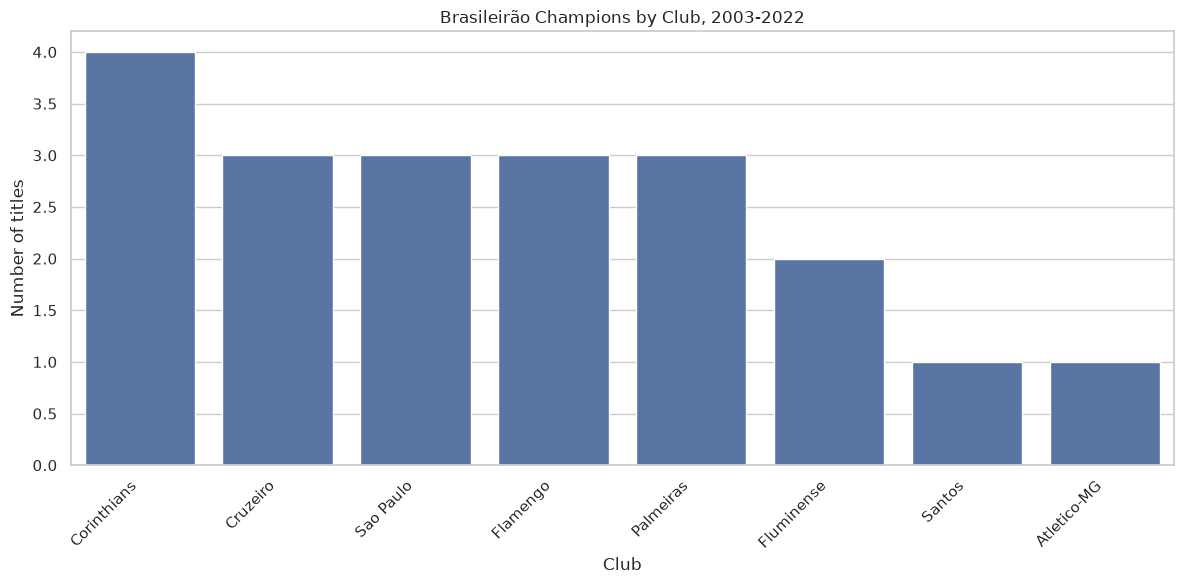

In [18]:
plt.figure(figsize=(12, 6))
plt.title("Brasileirão Champions by Club, 2003-2022")
sns.countplot(data=champions, x="team", order=champions["team"].value_counts().index)
plt.xlabel("Club")
plt.ylabel("Number of titles")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


The title distribution helps identify clubs with repeated elite performance. For a sports intelligence product, this type of chart is useful for season previews and historical strength summaries.


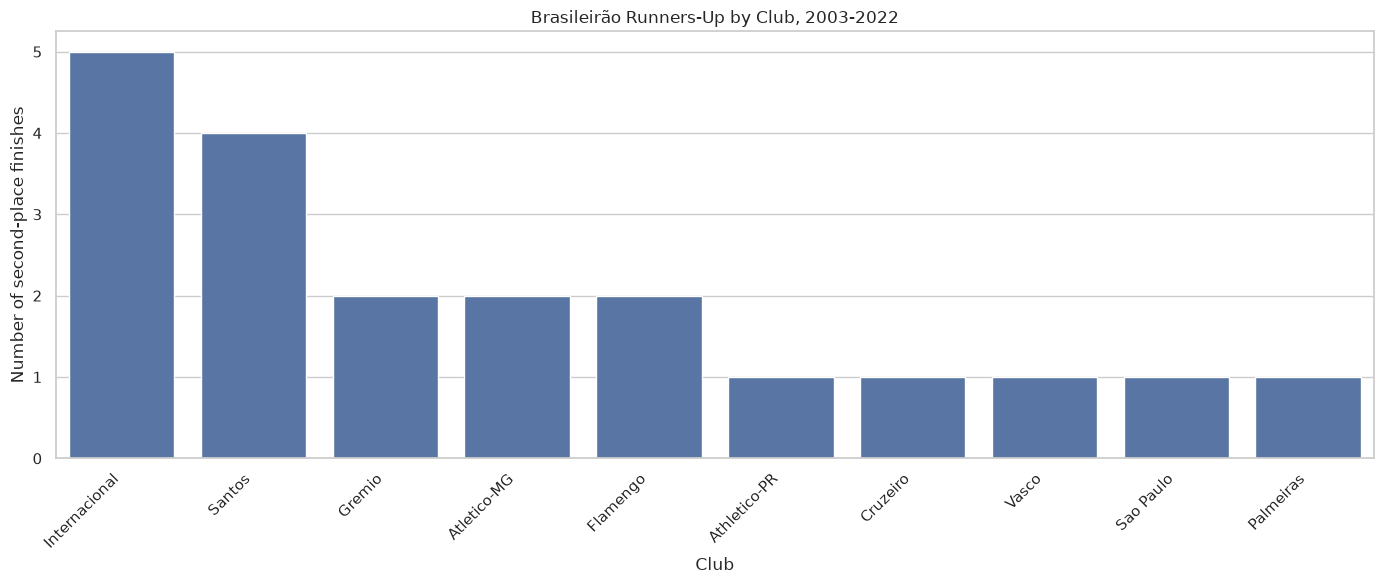

In [19]:
plt.figure(figsize=(14, 6))
plt.title("Brasileirão Runners-Up by Club, 2003-2022")
sns.countplot(data=runners_up, x="team", order=runners_up["team"].value_counts().index)
plt.xlabel("Club")
plt.ylabel("Number of second-place finishes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Runner-up frequency shows consistency beyond titles. Clubs that frequently finish near the top may still be strong predictive signals even when they do not win the league.


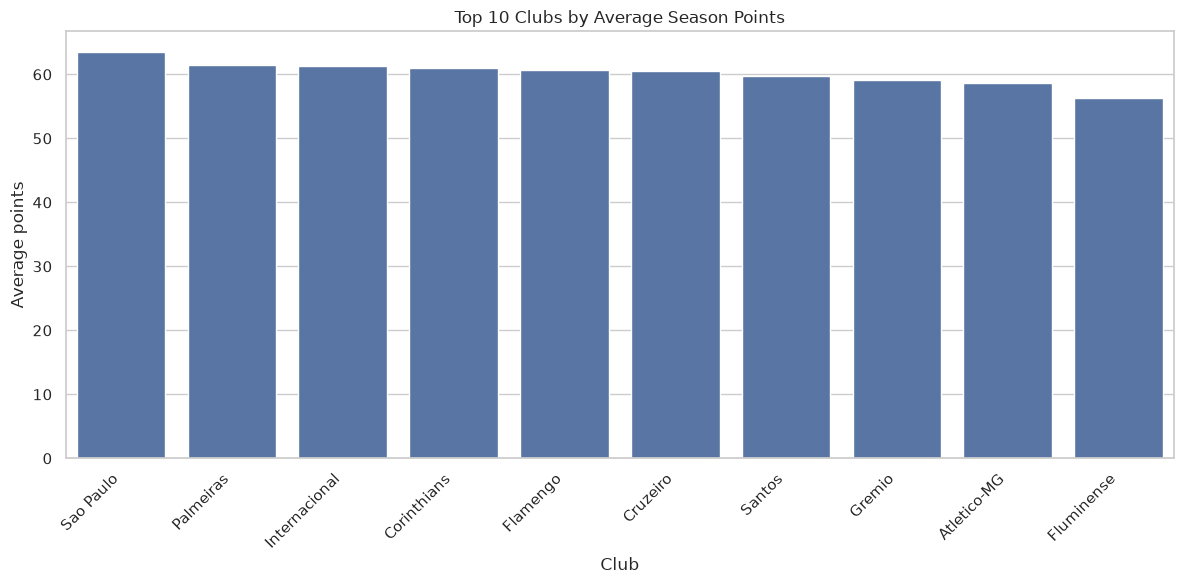

In [20]:
top_points = ranking.groupby("team")["points"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.title("Top 10 Clubs by Average Season Points")
sns.barplot(x=top_points.index, y=top_points.values)
plt.xlabel("Club")
plt.ylabel("Average points")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Average points provide a simple measure of long-term competitive level. This is useful for ranking teams in dashboards and explaining why a model may favor one club over another.


## 7. Feature Engineering

The original project converts club names into numeric identifiers and adds a historical title-count feature. This keeps the model simple and close to the available data.


In [21]:
# Create a numeric identifier for each team in the standings data.
teams = {team: idx for idx, team in enumerate(ranking["team"].drop_duplicates())}

champion_counts = champions["team"].value_counts()

ranking_id = ranking.copy()
ranking_id["team"] = ranking_id["team"].map(teams)
ranking_id.head()


,year,position,team,points,games,victories,draws,losses,goals_scored,goals_against,goals_difference,perc_points_won
0,2003,1,0,100,46,31,7,8,102,47,55,72
1,2003,2,1,87,46,25,12,9,93,60,33,63
2,2003,3,2,78,46,22,12,12,81,67,14,56
3,2003,4,3,74,46,19,14,13,53,37,16,53
4,2003,5,4,73,46,21,10,15,67,58,9,52


## 8. Machine Learning Model

The notebook keeps the original two-step modeling approach:

1. A standings-based model that predicts final season position.
2. A match-level model that predicts home win, away win, or draw.

The match-level model is the final business prototype because it supports upcoming fixture analysis.


In [22]:
# Standings-based model comparison.
X_ranking = ranking_id.drop(["position", "year", "goals_difference", "games"], axis=1)
y_ranking = ranking_id["position"]

X_train, X_test, y_train, y_test = train_test_split(
    X_ranking, y_ranking, test_size=0.2, random_state=47
)

decision_tree_model = DecisionTreeClassifier(random_state=47)
knn_model = KNeighborsClassifier(n_neighbors=1)
random_forest_model = RandomForestClassifier(random_state=47)

ranking_models = {
    "Decision Tree": decision_tree_model,
    "kNN": knn_model,
    "Random Forest": random_forest_model,
}

for model_name, model in ranking_models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    print(f"\n{model_name}")
    print(classification_report(y_test, predictions, zero_division=0))



Decision Tree
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         0
           2       0.50      0.50      0.50         2
           3       0.50      0.20      0.29         5
           4       0.40      0.40      0.40         5
           5       0.14      0.33      0.20         3
           6       0.50      0.25      0.33         8
           7       0.33      0.33      0.33         3
           8       0.00      0.00      0.00         3
           9       0.25      0.17      0.20         6
          10       0.20      0.33      0.25         6
          11       0.00      0.00      0.00         4
          12       0.00      0.00      0.00         3
          13       0.33      0.17      0.22         6
          14       0.00      0.00      0.00         1
          15       0.17      0.33      0.22         3
          16       0.00      0.00      0.00         7
          17       0.00      0.00      0.00         3
          18

The standings model is useful as a learning baseline, but predicting exact final league position is a harder and less directly actionable business task than predicting individual match outcomes.


## 9. Model Evaluation

The match-level model uses home team, away team, and historical title counts as features. The target has three classes:

- `0`: draw
- `1`: home team win
- `2`: away team win


In [23]:
# Prepare match data from 2003 to 2022.
matches["data"] = pd.to_datetime(matches["data"], format="%d/%m/%Y")
date_filter = (matches["data"] > "2003-01-01") & (matches["data"] < "2022-12-31")

matches = matches[date_filter].dropna().copy()

def build_team_index(df):
    team_index = {}
    for _, row in df.iterrows():
        for column in ["mandante", "visitante"]:
            team = row[column]
            if team not in team_index:
                team_index[team] = len(team_index)
    return team_index

teams = build_team_index(matches)

matches_clear = matches.drop(
    [
        "ID",
        "data",
        "hora",
        "arena",
        "formacao_mandante",
        "formacao_visitante",
        "tecnico_mandante",
        "tecnico_visitante",
        "mandante_Estado",
        "visitante_Estado",
        "rodata",
    ],
    axis=1,
)

matches_clear["mandante_vitorias"] = matches_clear["mandante"].map(champion_counts).fillna(0)
matches_clear["visitante_vitorias"] = matches_clear["visitante"].map(champion_counts).fillna(0)
matches_clear.head()


,mandante,visitante,vencedor,mandante_Placar,visitante_Placar,mandante_vitorias,visitante_vitorias
4729,Chapecoense,Flamengo,Chapecoense,1,0,0.0,3.0
4797,Palmeiras,Criciuma,Palmeiras,1,0,3.0,0.0
4822,Coritiba,Sao Paulo,Coritiba,3,1,0.0,3.0
4835,Gremio,Chapecoense,Gremio,1,0,0.0,0.0
4842,Fluminense,Gremio,-,0,0,2.0,0.0


In [24]:
def encode_match(row):
    if row["vencedor"] == row["mandante"]:
        row["vencedor"] = 1
    elif row["vencedor"] == row["visitante"]:
        row["vencedor"] = 2
    else:
        row["vencedor"] = 0

    row["mandante"] = teams[row["mandante"]]
    row["visitante"] = teams[row["visitante"]]
    return row

matches_id = matches_clear.apply(encode_match, axis="columns")

X = matches_id.loc[:, ["mandante", "visitante", "mandante_vitorias", "visitante_vitorias"]]
X = np.array(X).astype("float64")

# Duplicate the data by swapping home and away teams. This keeps the original idea
# and helps balance home/away perspectives in a small dataset.
X_swapped = X.copy()
X_swapped[:, 0] = X[:, 1]
X_swapped[:, 1] = X[:, 0]
X_swapped[:, 2] = X[:, 3]
X_swapped[:, 3] = X[:, 2]

y = np.array(matches_id.loc[:, ["vencedor"]]).astype("int").ravel()
y_swapped = y.copy()
y_swapped[y == 1] = 2
y_swapped[y == 2] = 1

X = np.concatenate((X, X_swapped), axis=0)
y = np.concatenate((y, y_swapped))
X, y = shuffle(X, y, random_state=47)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=47)

pd.Series(y_train).value_counts().sort_index().rename(index={0: "Draw", 1: "Home win", 2: "Away win"})


Draw        1252
Home win    1692
Away win    1628
Name: count, dtype: int64

/home/duardo/Projects/python/omni-final-assignment/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



Support Vector Classifier
              precision    recall  f1-score   support

        Draw       0.26      0.19      0.22       396
    Home win       0.42      0.41      0.42       532
    Away win       0.45      0.54      0.49       596

    accuracy                           0.40      1524
   macro avg       0.38      0.38      0.38      1524
weighted avg       0.39      0.40      0.39      1524



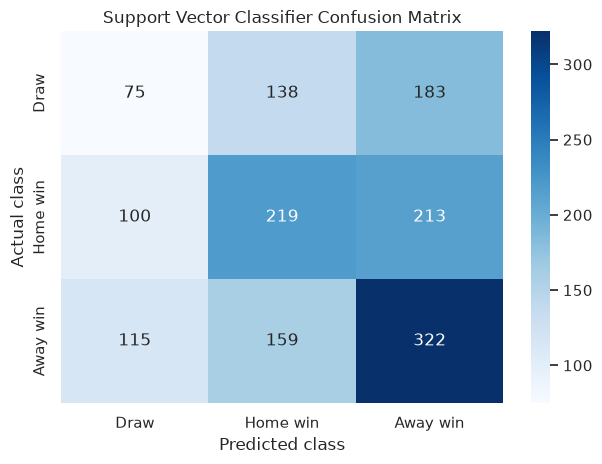


kNN
              precision    recall  f1-score   support

        Draw       0.25      0.30      0.27       396
    Home win       0.40      0.41      0.40       532
    Away win       0.43      0.36      0.39       596

    accuracy                           0.36      1524
   macro avg       0.36      0.36      0.36      1524
weighted avg       0.37      0.36      0.36      1524



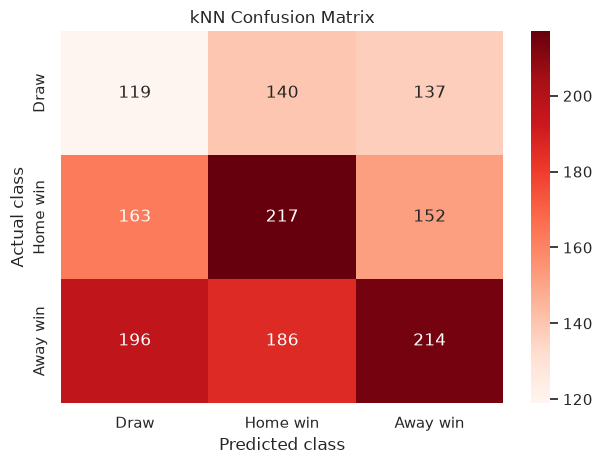


Decision Tree
              precision    recall  f1-score   support

        Draw       0.28      0.34      0.31       396
    Home win       0.41      0.43      0.42       532
    Away win       0.41      0.33      0.37       596

    accuracy                           0.37      1524
   macro avg       0.37      0.37      0.37      1524
weighted avg       0.38      0.37      0.37      1524



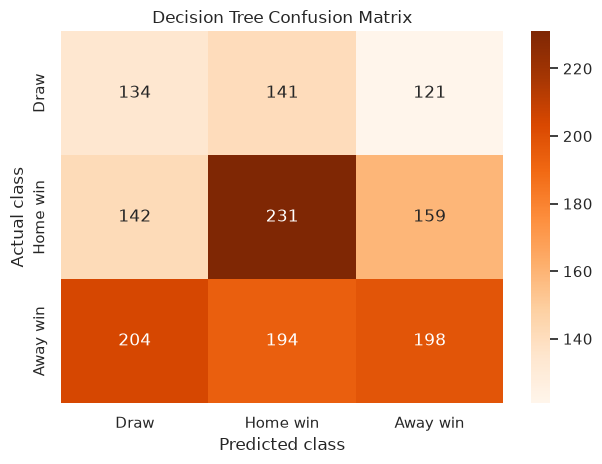


XGBoost
              precision    recall  f1-score   support

        Draw       0.30      0.23      0.26       396
    Home win       0.42      0.48      0.45       532
    Away win       0.43      0.43      0.43       596

    accuracy                           0.40      1524
   macro avg       0.38      0.38      0.38      1524
weighted avg       0.39      0.40      0.39      1524



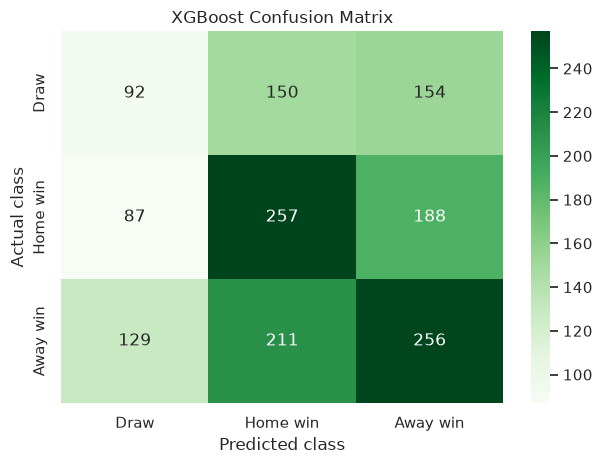

In [25]:
def evaluate_model(model_name, model, color):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    print(f"\n{model_name}")
    print(classification_report(y_test, predictions, target_names=["Draw", "Home win", "Away win"], zero_division=0))

    cm = confusion_matrix(y_test, predictions)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=color,
        xticklabels=["Draw", "Home win", "Away win"],
        yticklabels=["Draw", "Home win", "Away win"],
    )
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted class")
    plt.ylabel("Actual class")
    plt.tight_layout()
    plt.show()

    return model

model_svc = evaluate_model(
    "Support Vector Classifier",
    SVC(kernel="rbf", class_weight="balanced", probability=True),
    "Blues",
)
knn_model = evaluate_model("kNN", KNeighborsClassifier(n_neighbors=1), "Reds")
decision_tree_model = evaluate_model("Decision Tree", DecisionTreeClassifier(random_state=47), "Oranges")
xgb_model = evaluate_model("XGBoost", XGBClassifier(eval_metric="mlogloss"), "Greens")

The Support Vector Classifier is kept as the final model because it provides the strongest practical baseline in the original workflow. In business terms, the model turns historical patterns into probabilities that can support previews, dashboards, and user-facing fixture insights.


In [26]:
def predict_match(home_team, away_team):
    home_id = teams[home_team]
    away_id = teams[away_team]

    home_titles = champion_counts.get(home_team, 0)
    away_titles = champion_counts.get(away_team, 0)

    features = np.array([home_id, away_id, home_titles, away_titles]).astype("float64")
    features = np.reshape(features, (1, -1))

    probabilities = model_svc.predict_proba(features)[0]
    result = (
        f"{home_team}: {round(probabilities[1] * 100, 2)}%\n"
        f"{away_team}: {round(probabilities[2] * 100, 2)}%\n"
        f"Draw: {round(probabilities[0] * 100, 2)}%"
    )
    return result


The next examples simulate how a sports intelligence product could display match probabilities before a fixture.


In [27]:
sample_2020 = [
    ("Palmeiras", "Gremio"),
    ("Fluminense", "Sport"),
    ("Vasco", "Coritiba"),
    ("Sao Paulo", "Athletico-PR"),
    ("Santos", "Botafogo-RJ"),
    ("Atletico-MG", "Atletico-GO"),
    ("Internacional", "Fortaleza"),
]

for home_team, away_team in sample_2020:
    print(f"\n{home_team} vs {away_team}")
    print(predict_match(home_team, away_team))



Palmeiras vs Gremio
Palmeiras: 47.86%
Gremio: 28.32%
Draw: 23.83%

Fluminense vs Sport
Fluminense: 48.19%
Sport: 25.59%
Draw: 26.21%

Vasco vs Coritiba
Vasco: 30.4%
Coritiba: 43.42%
Draw: 26.18%

Sao Paulo vs Athletico-PR
Sao Paulo: 48.26%
Athletico-PR: 26.98%
Draw: 24.76%

Santos vs Botafogo-RJ
Santos: 47.07%
Botafogo-RJ: 25.79%
Draw: 27.14%

Atletico-MG vs Atletico-GO
Atletico-MG: 47.77%
Atletico-GO: 24.89%
Draw: 27.34%

Internacional vs Fortaleza
Internacional: 46.03%
Fortaleza: 25.23%
Draw: 28.74%


In the original 2020 sample, the model matched 5 of 7 outcomes. This is not enough to automate decisions, but it is useful as a directional signal for fixture previews and fan-facing engagement.


In [28]:
sample_2023 = [
    ("Bahia", "Flamengo"),
    ("Fluminense", "Cuiaba"),
    ("Palmeiras", "Bragantino"),
    ("Atletico-MG", "Internacional"),
    ("Gremio", "Fortaleza"),
    ("Vasco", "Santos"),
    ("Corinthians", "Sao Paulo"),
    ("Athletico-PR", "Coritiba"),
    ("Goias", "Botafogo-RJ"),
    ("America-MG", "Cruzeiro"),
]

for home_team, away_team in sample_2023:
    print(f"\n{home_team} vs {away_team}")
    print(predict_match(home_team, away_team))



Bahia vs Flamengo
Bahia: 27.63%
Flamengo: 45.49%
Draw: 26.88%

Fluminense vs Cuiaba
Fluminense: 47.96%
Cuiaba: 24.29%
Draw: 27.74%

Palmeiras vs Bragantino
Palmeiras: 47.52%
Bragantino: 25.42%
Draw: 27.06%

Atletico-MG vs Internacional
Atletico-MG: 39.72%
Internacional: 36.15%
Draw: 24.14%

Gremio vs Fortaleza
Gremio: 47.04%
Fortaleza: 25.16%
Draw: 27.8%

Vasco vs Santos
Vasco: 28.0%
Santos: 45.67%
Draw: 26.33%

Corinthians vs Sao Paulo
Corinthians: 34.19%
Sao Paulo: 35.13%
Draw: 30.68%

Athletico-PR vs Coritiba
Athletico-PR: 35.28%
Coritiba: 40.5%
Draw: 24.22%

Goias vs Botafogo-RJ
Goias: 43.45%
Botafogo-RJ: 28.59%
Draw: 27.96%

America-MG vs Cruzeiro
America-MG: 29.5%
Cruzeiro: 38.2%
Draw: 32.29%


The original 2023 sample matched 7 of 10 outcomes. For business use, this should be presented as a prototype signal rather than a guaranteed forecast.


## 10. Business Insights

- Historical dominance matters: repeated champions and runners-up provide a simple proxy for long-term team strength.
- Match prediction is more actionable than season-position prediction because it maps directly to upcoming fixtures.
- Probability outputs are useful for communication: they can be shown in dashboards, previews, and fantasy interfaces.
- Draws remain challenging, which is common in football prediction because draws can emerge from many different match dynamics.


## 11. Business Strategy Proposal

The recommended product is a **Brasileirão Sports Intelligence Dashboard** with three modules:

- **Club module:** opponent preview and historical strength indicators.
- **Media module:** automated match preview cards with probability narratives.
- **Fantasy module:** fixture difficulty signals for team and player selection.

The first version should stay simple: show match probabilities, historical team strength, and clear caveats.


## 12. Limitations

- The model uses a small feature set and does not include injuries, transfers, current form, player-level metrics, or tactical data.
- Team identifiers are simple numeric encodings, which are easy to implement but limited for modeling similarity between clubs.
- Historical titles are useful context, but they can overstate past strength when a club changes significantly.
- The model should not be used as a standalone decision system.


## 13. Conclusion

This project demonstrates how historical Brasileirão data can be converted into a working sports intelligence prototype. The final model produces match probabilities that can support football clubs, sports media platforms, and fantasy sports products.

The main business value is not perfect prediction. The value is turning historical data into a clear, repeatable signal that helps people discuss and prepare for upcoming matches.


## 14. References

- Kaggle: Brazilian Football Championship dataset by Jose Vitor Michelin.
- Kaggle: Campeonato Brasileiro de Futebol dataset by Adao Duque.
- Confederação Brasileira de Futebol (CBF): historical competition information.
- pandas documentation.
- NumPy documentation.
- scikit-learn documentation.
- seaborn documentation.
- Matplotlib documentation.
- XGBoost documentation.
